<a href="https://colab.research.google.com/github/AnjanaGunarathna/DL_News_Detection/blob/Samudra(CNN)/DLAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Required Libraries:

In [1]:
!pip install kaggle tensorflow scikit-learn

Mount Drive & Load Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

fake_df = pd.read_csv('/content/drive/MyDrive/Fake.csv')
true_df = pd.read_csv('/content/drive/MyDrive/True.csv')

# Add labels: 0 = fake, 1 = real
fake_df['label'] = 0
true_df['label'] = 1

# Combine datasets
df = pd.concat([fake_df[['title','text','label']], true_df[['title','text','label']]], ignore_index=True)

# Combine title + text for better representation
df['text'] = df['title'] + ' ' + df['text']
df = df[['text','label']]

Mounted at /content/drive


Text Preprocessing

In [3]:
import re
def preprocess_text(text):
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove non-alphabet characters
    text = text.lower().strip()
    return text

df['text'] = df['text'].apply(preprocess_text)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42)


Tokenization & Padding

In [4]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 15000
max_len = 5000

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, padding='post', maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, padding='post', maxlen=max_len)

Build Text CNN Model

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128),
    Conv1D(128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.build(input_shape=(None, max_len))
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 5000, 128)      │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 4996, 128)      │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,018,689 (7.70 MB)

 Trainable params: 2,018,689 (7.70 MB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [6]:
history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 67s 104ms/step - accuracy: 0.9104 - loss: 0.1959 - val_accuracy: 0.9997 - val_loss: 0.0016
Epoch 2/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 54s 97ms/step - accuracy: 0.9995 - loss: 0.0015 - val_accuracy: 0.9997 - val_loss: 7.9595e-04
Epoch 3/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 54s 97ms/step - accuracy: 1.0000 - loss: 1.3400e-04 - val_accuracy: 0.9997 - val_loss: 0.0014
Epoch 4/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 54s 97ms/step - accuracy: 1.0000 - loss: 6.2021e-05 - val_accuracy: 0.9997 - val_loss: 0.0010
Epoch 5/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 55s 97ms/step - accuracy: 1.0000 - loss: 3.5213e-05 - val_accuracy: 0.9997 - val_loss: 8.6824e-04
Epoch 6/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 54s 97ms/step - accuracy: 1.0000 - loss: 1.2727e-05 - val_accuracy: 0.9997 - val_loss: 9.2762e-04
Epoch 7/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 54s 97ms/step - accuracy: 1.0000 - loss: 5.7831e-06 - val_accuracy: 0.9997 - val_loss: 9.7831e-04
Epoch 8/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 54s 97ms/step

Evaluate Model

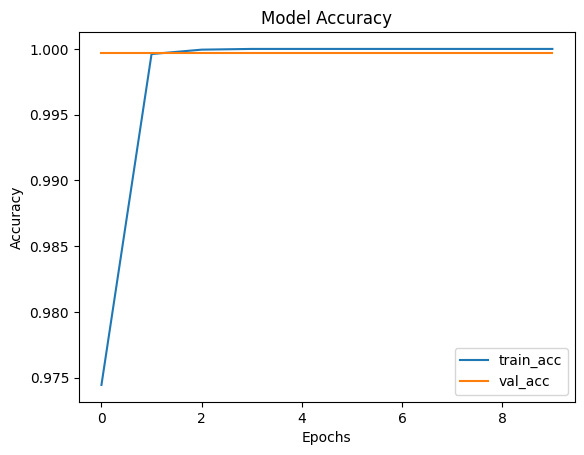

281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Confusion Matrix:
 [[4731    2]
 [   1 4246]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4733
           1       1.00      1.00      1.00      4247

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Plot training history
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Predictions & metrics
y_pred = (model.predict(X_test_pad) > 0.5).astype("int32")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Full Detection

In [8]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("📰 Fake News Detector")
print("Type 'exit' to quit.\n")

while True:
    # Ask user to enter news
    news_text = input("Enter news article: ")

    if news_text.lower() == "exit":
        print("Exiting the detector. Goodbye! 👋")
        break

    # Wrap in list (tokenizer expects a list)
    new_text = [news_text]

    # Tokenize + pad (same tokenizer and maxlen as training)
    new_seq = tokenizer.texts_to_sequences(new_text)
    new_padded = pad_sequences(new_seq, maxlen=50000)

    # Predict with trained CNN model
    prediction = model.predict(new_padded)

    # Show result
    if prediction[0][0] > 0.5:
        print("✅ This news is classified as REAL 📰")
    else:
        print("❌ This news is classified as FAKE 🚨")

    print("🔎 Confidence score:", float(prediction[0][0]))
    print("\n----------------------------\n")



📰 Fake News Detector
Type 'exit' to quit.

Enter news article: trump-antifa Government U.S. Outlines Plans to Dismantle Domestic Terror Org Antifa
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step
❌ This news is classified as FAKE 🚨
🔎 Confidence score: 3.7746687553408265e-07

----------------------------

Enter news article: Washington, D.C. – Earlier this week, President Trump hosted a White House roundtable to address the escalating violence attributed to Antifa, labeling it a domestic terrorist organization. Joined by Attorney General Pam Bondi, Secretary Kristi Noem, FBI Director Kash Patel, and independent journalists, the administration outlined a robust response to Antifa’s actions.  Antifa’s campaign of violence—targeting ICE agents, journalists, and federal property—has surged, with incidents in Portland, Chicago, and Los Angeles. The group’s decentralized structure and funding from complex networks, including NGOs and foreign sources, pose a significant challenge to law enforcement.
1/1

KeyboardInterrupt: Interrupted by user